--- Feature Types ---
Numeric columns (9): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


--- Numeric Feature Distributions ---


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



--- Skewness of Numeric Features ---
age               0.784697
campaign          4.762507
pdays            -4.922190
previous          3.832042
emp.var.rate     -0.724096
cons.price.idx   -0.230888
cons.conf.idx     0.303180
euribor3m        -0.709188
nr.employed      -1.044262
dtype: float64

--- Category Counts ---

Counts for job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Counts for marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Counts for education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown               

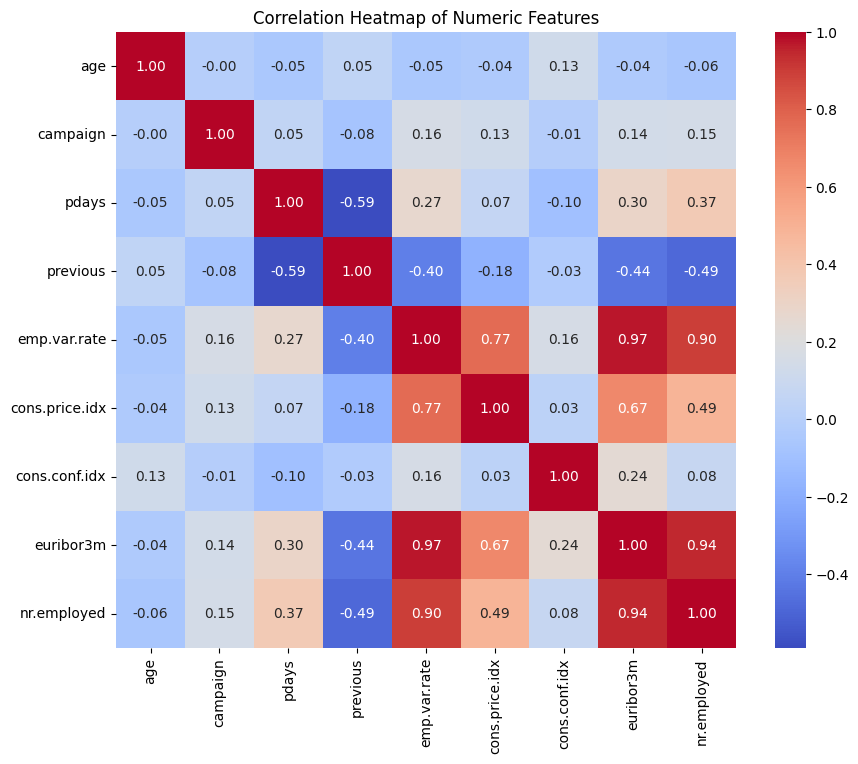

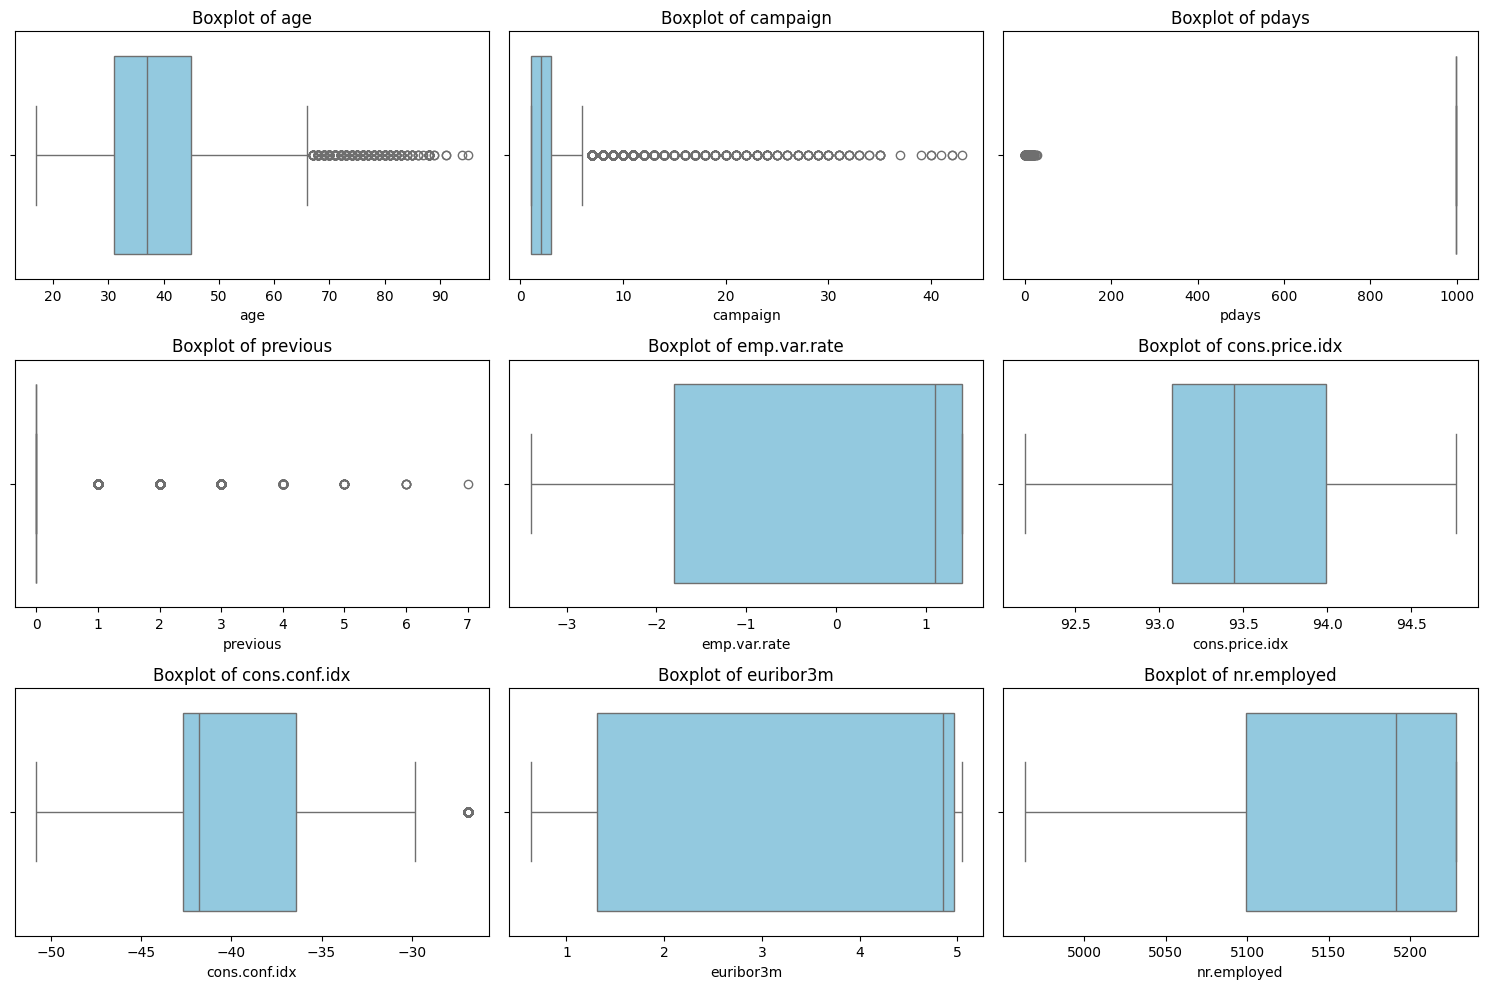

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r'D:\semester 10\[NETW1013] Machine Learning\Lab 1\bank+marketing\bank-additional\bank-additional\bank-additional-full.csv', sep=';')

# Drop 'y' because this is an unsupervised clustering task.
# Drop 'duration' because it occurs during the call and isn't useful for predictive clustering beforehand.
df = df.drop(columns=['y', 'duration'])

# Identify numeric vs categorical features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("--- Feature Types ---")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols.tolist()}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols.tolist()}\n")

# Check distributions of numeric features (min, max, mean, std)
print("\n--- Numeric Feature Distributions ---")
display(df.describe())

# Check Skewness of numeric features
print("\n--- Skewness of Numeric Features ---")
print(df[numeric_cols].skew())

# ADDED: Check counts of categories for categorical features
print("\n--- Category Counts ---")
for col in categorical_cols:
    print(f"\nCounts for {col}:")
    print(df[col].value_counts())

# Identify unknown values within categorical features
print("\n--- 'Unknown' Values Count Before Handling ---")
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"Column '{col}' has {unknown_count} 'unknown' values.")

# Decide how to handle missing or unknown values
# We treat 'unknown' as missing data and drop those clients to ensure clean clusters.
df = df.replace('unknown', np.nan).dropna()
print(f"\nDataset shape after dropping unknown values: {df.shape}")

# Look for correlations between numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Identify outliers that may affect clustering
plt.figure(figsize=(15, 10))
# Create a grid of boxplots for each numeric feature
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

print("--- Encoding Categorical Features ---")
print(f"Original dataset shape: {df.shape}")

# Encode categorical features into numeric format
# pd.get_dummies converts categorical variables into 1/0 indicator columns.
# drop_first=True helps prevent multicollinearity (dummy variable trap).
df_prepared = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Dataset shape after One-Hot Encoding: {df_prepared.shape}\n")

# Scale numeric features
scaler = StandardScaler()

# We fit and transform only the original numeric columns. 
# We don't need to scale the new 1/0 dummy columns.
print("--- Scaling Numeric Features ---")
df_prepared[numeric_cols] = scaler.fit_transform(df_prepared[numeric_cols])
print("Scaling complete.\n")

# Check that the final dataset has no missing values and all features are numeric
print("--- Final Dataset Verification ---")
total_missing = df_prepared.isnull().sum().sum()
print(f"Total missing values in the entire dataset: {total_missing}")

# Check data types (everything should be a number: bool, int, or float)
print("\nFeature Data Types:")
print(df_prepared.dtypes.value_counts())

# Display the first few rows of our dataset
display(df_prepared.head())

--- Encoding Categorical Features ---
Original dataset shape: (30488, 19)
Dataset shape after One-Hot Encoding: (30488, 46)

--- Scaling Numeric Features ---
Scaling complete.

--- Final Dataset Verification ---
Total missing values in the entire dataset: 0

Feature Data Types:
bool       37
float64     9
Name: count, dtype: int64


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,1.642253,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,True,False,False,False,True,False,False,False,True,False
2,-0.196452,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,True,False,False,False,True,False,False,False,True,False
3,0.093870,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,True,False,False,False,True,False,False,False,True,False
4,1.642253,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,True,False,False,False,True,False,False,False,True,False
6,1.932575,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,True,False,False,False,True,False,False,False,True,False


In [9]:
from sklearn.cluster import KMeans

# Decide an initial number of clusters (K)
# We are choosing 4 as our initial guess.
initial_k = 4
print(f"--- Applying K-Means with K={initial_k} ---")

# Fit the K-Means model to your prepared dataset
kmeans_model = KMeans(n_clusters=initial_k, random_state=42, n_init='auto')

# Assign each data point to a cluster
# fit_predict does the math and instantly hands back a cluster number (0, 1, 2, or 3) for every client
cluster_assignments = kmeans_model.fit_predict(df_prepared)

# add these assignments as a brand new column at the end of the prepared dataset
df_prepared['Cluster'] = cluster_assignments

print("K-Means training complete!")

# how many clients the math robot put into each of the 4 buckets
print("\nNumber of clients assigned to each cluster:")
print(df_prepared['Cluster'].value_counts().sort_index())

# first 5 rows with new Cluster column
display(df_prepared.head())

--- Applying K-Means with K=4 ---
K-Means training complete!

Number of clients assigned to each cluster:
Cluster
0     7271
1     9887
2    11979
3     1351
Name: count, dtype: int64


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,Cluster
0,1.642253,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,False,False,False,True,False,False,False,True,False,0
2,-0.196452,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,False,False,False,True,False,False,False,True,False,2
3,0.093870,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,False,False,False,True,False,False,False,True,False,2
4,1.642253,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,False,False,False,True,False,False,False,True,False,0
6,1.932575,-0.559335,0.211887,-0.371616,0.727477,0.804095,0.877451,0.786102,0.401648,False,...,False,False,False,True,False,False,False,True,False,0


Calculating SSD and Silhouette Scores


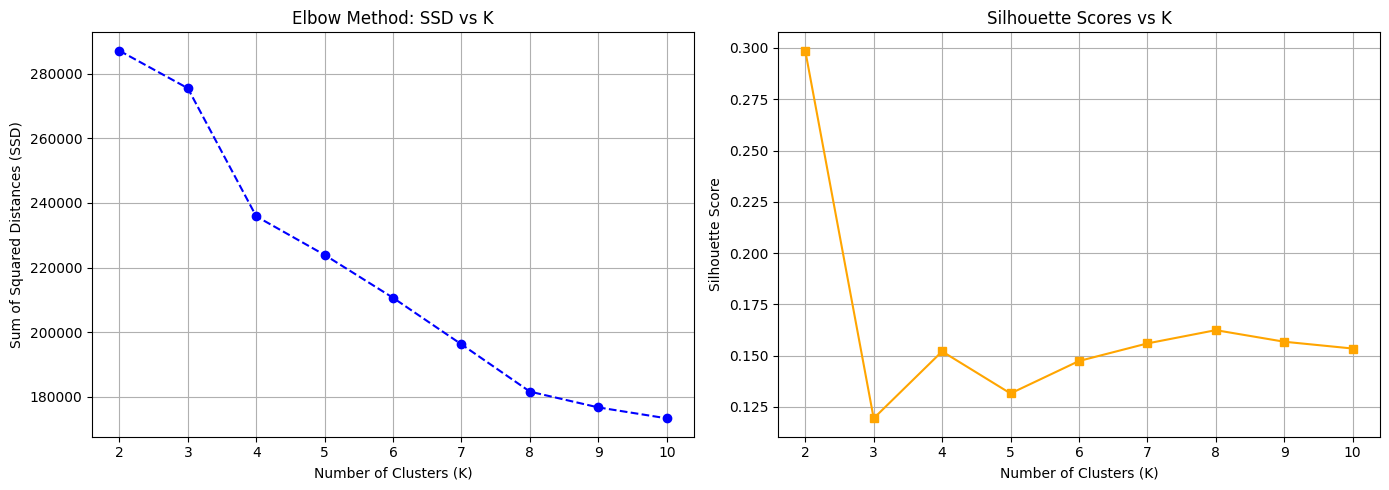

In [10]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range = range(2, 11)
ssd = []
silhouette_scores = []

print("Calculating SSD and Silhouette Scores")

for k in K_range:
    # Fit the model for the current K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    data_for_clustering = df_prepared.drop(columns=['Cluster'], errors='ignore')
    
    kmeans.fit(data_for_clustering)
    
    # Get the Sum of Squared Distances
    ssd.append(kmeans.inertia_)
    
    # Calculate Silhouette Score
    sil_score = silhouette_score(data_for_clustering, kmeans.labels_)
    silhouette_scores.append(sil_score)

# Plotting the Elbow Method (SSD vs K)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, ssd, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method: SSD vs K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.grid(True)

# Plotting Silhouette Scores vs K
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='orange')
plt.title('Silhouette Scores vs K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()